# How the energy grid resolution affects the xs perturbation

In [1]:
import sandy
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

## Retrieve ENDF-6 file

In [3]:
tape = sandy.get_endf6_file("endfb_80", "xs", 942390)

## Create PENDF files by parametrically varying reconstruction tolerance ERR

In [4]:
pendf_1 = tape.get_pendf(
    purr=False,
    heatr=False,
    gaspr=False,
    verbose=True,
    err=1,
)
xs_1 = sandy.Xs.from_endf6(pendf_1)

get_pendf | ZAM=942390 | augmented NJOY kwargs: { 'acer': False,
  'broadr': False,
  'broadr_kws': {'err': 1.0},
  'dryrun': False,
  'gaspr': False,
  'heatr': False,
  'purr': False,
  'reconr_kws': {'err': 1.0},
  'temperatures': [0],
  'thermr': False,
  'thermr_kws': {'err': 1.0},
  'unresr': False}


get_pendf | ZAM=942390 | run NJOY



 njoy 2016.79  18Mar25                                       07/13/26 16:57:49
 *****************************************************************************

 moder...                                                                 0.0s



 reconr...                                                                0.5s

 ---message from rdf2bw---calculation of angular distribution not installed.



 moder...                                                                 1.7s


_run_njoy | ZAM=942390 | NJOY ran in 3.347 s


get_pendf | ZAM=942390 | parsing NJOY PENDF output into Endf6 structure


                                                                          1.9s
 *****************************************************************************


In [5]:
pendf_01 = tape.get_pendf(err=0.1)
xs_01 = sandy.Xs.from_endf6(pendf_01)


 njoy 2016.79  18Mar25                                       07/13/26 16:57:53
 *****************************************************************************

 moder...                                                                 0.0s



 reconr...                                                                0.5s

 ---message from rdf2bw---calculation of angular distribution not installed.



 moder...                                                                 2.9s


                                                                          3.4s
 *****************************************************************************


In [6]:
pendf_001 = tape.get_pendf(err=0.01)
xs_001 = sandy.Xs.from_endf6(pendf_001)


 njoy 2016.79  18Mar25                                       07/13/26 16:57:58
 *****************************************************************************

 moder...                                                                 0.0s



 reconr...                                                                0.5s

 ---message from rdf2bw---calculation of angular distribution not installed.



 moder...                                                                 7.3s


                                                                          8.6s
 *****************************************************************************


In [7]:
pendf_0001 = tape.get_pendf(err=0.001)
xs_0001 = sandy.Xs.from_endf6(pendf_0001)


 njoy 2016.79  18Mar25                                       07/13/26 16:58:09
 *****************************************************************************

 moder...                                                                 0.0s



 reconr...                                                                0.5s

 ---message from rdf2bw---calculation of angular distribution not installed.



 moder...                                                                17.5s


                                                                         20.8s
 *****************************************************************************


## Extract cross sections and perturb them in energy bin

In [8]:
pert_coeff = 1
ipert = 25

egrid = sandy.energy_grids.SCALE238
estart = egrid[ipert]
estop = egrid[ipert+1]

pert = sandy.Pert([1, 1 + pert_coeff], index=[estart, estop])

print(
    f"""
Perturb fission xs in range ({estart}, {estop}) eV by a factor {pert_coeff*100} %.
Perturbation object is:
{pert}
"""
 )


Perturb fission xs in range (0.175, 0.19999999999999998) eV by a factor 100 %.
Perturbation object is:
ENERGY
(0.0, 0.175]                    1.0
(0.175, 0.19999999999999998]    2.0
dtype: float64



In [9]:
mat = tape.mat[0]
mt = 18

xspert_1 = xs_1.custom_perturbation(mat, mt, pert)
xspert_01 = xs_01.custom_perturbation(mat, mt, pert)
xspert_001 = xs_001.custom_perturbation(mat, mt, pert)
xspert_0001 = xs_0001.custom_perturbation(mat, mt, pert)

## Analyize how the perturbation was implemented

In [10]:
def apply_mask(xs, estart, estop):
    mask = (xs.data.index >= estart) & (xs.data.index <= estop)
    return xs.data.loc[mask]

### ERR=1

In [11]:
print(
    f"""
No point was was found in the selected energy interval with a very low reconstruction tolerance.

{apply_mask(xs_1, estart, estop)[mat, mt].rename("ORIGINAL")}

Points {estart} and {estop} were interpolated and then perurbed in the perturbed xs.

{apply_mask(xspert_1, estart, estop)[mat, mt].rename("PERTURBED")}
"""
)


No point was was found in the selected energy interval with a very low reconstruction tolerance.

Series([], Name: ORIGINAL, dtype: float64)

Points 0.175 and 0.19999999999999998 were interpolated and then perurbed in the perturbed xs.

E
0.175     696.1199
0.200    1688.9588
Name: PERTURBED, dtype: float64



### ERR=0.001

In [12]:
print(
    f"""
Many points were found.

{apply_mask(xs_0001, estart, estop)[mat, mt].rename("ORIGINAL")}

Point {estop} was added to the perturbed xs because not present in the original file.

{apply_mask(xspert_0001, estart, estop)[mat, mt].rename("PERTURBED")}
"""
)


Many points were found.

E
0.175000    653.0286
0.176563    661.9591
0.178125    671.2262
0.179688    680.8424
0.181250    690.8208
0.182812    701.1748
0.184375    711.9188
0.185938    723.0677
0.187500    734.6373
0.189062    746.6439
0.190625    759.1048
0.192188    772.0379
0.193750    785.4621
0.195312    799.3972
0.196875    813.8639
0.198437    828.8837
Name: ORIGINAL, dtype: float64

Point 0.19999999999999998 was added to the perturbed xs because not present in the original file.

E
0.175000     653.0286
0.176563    1323.9182
0.178125    1342.4524
0.179688    1361.6848
0.181250    1381.6416
0.182812    1402.3496
0.184375    1423.8376
0.185938    1446.1354
0.187500    1469.2746
0.189062    1493.2878
0.190625    1518.2096
0.192188    1544.0758
0.193750    1570.9242
0.195312    1598.7944
0.196875    1627.7278
0.198437    1657.7674
0.200000    1688.9588
Name: PERTURBED, dtype: float64



### Visual analysis

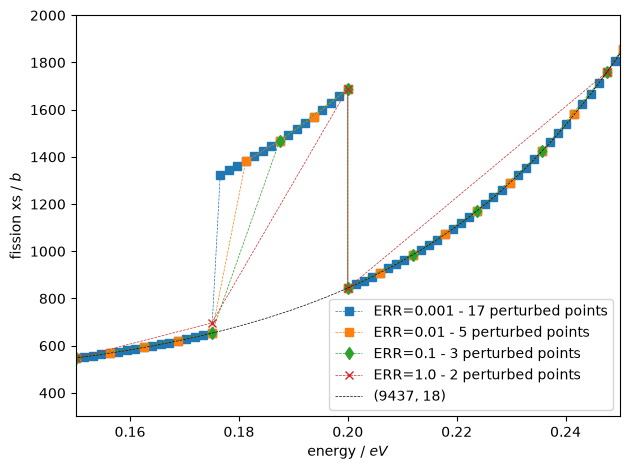

In [13]:
fig, ax = plt.subplots()

count = ((xspert_0001.data.index >= estart) & (xspert_0001.data.index <= estop)).sum()
ax = xspert_0001.data[mat, mt].plot(marker="s", ax=ax, ls="--", lw=.5, label=f"ERR=0.001 - {count} perturbed points")

count = ((xspert_001.data.index >= estart) & (xspert_001.data.index <= estop)).sum()
ax = xspert_001.data[mat, mt].plot(marker="s", ax=ax, ls="--", lw=.5, label=f"ERR=0.01 - {count} perturbed points")

count = ((xspert_01.data.index >= estart) & (xspert_01.data.index <= estop)).sum()
ax = xspert_01.data[mat, mt].plot(marker="d", ax=ax, ls="--", lw=.5, label=f"ERR=0.1 - {count} perturbed points")

count = ((xspert_1.data.index >= estart) & (xspert_1.data.index <= estop)).sum()
ax = xspert_1.data[mat, mt].plot(marker="x", ax=ax, ls="--", lw=.5, label=f"ERR=1.0 - {count} perturbed points")

ax = xs_0001.data[mat, mt].plot(ls="--", lw=.5, c="k", ax=ax)

ax.set(xlim=(0.15, 0.25), ylim=(300, 2000), xlabel='energy / $eV$', ylabel="fission xs / $b$")
ax.legend(loc=4)

fig.tight_layout()

## Conclusion

Using a low value for the reconstruction tolerance parameter ERR is necessary to reproduce the expected perturbation behavior.

Alternatively, additional points must be added manually to the cross sections.